In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import RobustScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report
import numpy as np


from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest


from xgboost import XGBClassifier

 Supervised Learning

In [ ]:
df_train = pd.read_csv('fraudTrain.csv', index_col=0)
df_test = pd.read_csv('fraudTest.csv', index_col=0)
df_train.columns

#data cleaning
df_train = df_train.dropna()
df_test = df_test.dropna()

In [ ]:
print(df_train.dtypes)

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


We take all the features that we can take without preprocessing. What we can convert to dummy, we will convert.

In [ ]:
#training on all data
def process_data_raw(df):

    keep_columns = ['cc_num', 'category', 'amt', 'gender', 'city_pop', 'zip', 'lat', 'long', 'unix_time', 'merch_lat', 'merch_long','is_fraud']
    df = df[keep_columns]

    cats = ['category', 'gender']
    df = pd.concat(
    [
        pd.get_dummies(df[cats]),
        df[df.columns.drop(cats)],

    ], axis=1)

    return df

df = process_data_raw(df_train)
df1 = process_data_raw(df_test)

x_test = df1[df1.columns.drop('is_fraud')]
y_test = df1.is_fraud
print(df1.columns.to_list)
print(df.columns.to_list)
print(x_test.columns.to_list)

fraud_org = df.query('is_fraud==1')
no_fraud_org = df.query('is_fraud==0')


#downsampling, we take random strings from "normal" transactions at a ratio of 10 to 1 compared to fraudulent transactions
df = pd.concat([
    no_fraud_org.sample(10*len(fraud_org), random_state=0),
    fraud_org,
])


x_train, x_val, y_train, y_val = train_test_split(df[df.columns.drop('is_fraud')],
                                                  df.is_fraud, test_size=0.25, random_state=0)


rf = RandomForestClassifier(random_state=0, class_weight='balanced')
rf.fit(x_train, y_train)
print('validation score', classification_report(y_val, rf.predict(x_val)))
for_compare1 = classification_report(y_test, rf.predict(x_test))
print('test score', classification_report(y_test, rf.predict(x_test)))

<bound method IndexOpsMixin.tolist of Index(['category_entertainment', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'gender_F', 'gender_M',
       'cc_num', 'amt', 'city_pop', 'zip', 'lat', 'long', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')>
<bound method IndexOpsMixin.tolist of Index(['category_entertainment', 'category_food_dining',
       'category_gas_transport', 'category_grocery_net',
       'category_grocery_pos', 'category_health_fitness', 'category_home',
       'category_kids_pets', 'category_misc_net', 'category_misc_pos',
       'category_personal_care', 'category_shopping_net',
       'category_shopping_pos', 'category_travel', 'gender_F', 'gender_M

In [ ]:
print(df.dtypes)

category_entertainment        bool
category_food_dining          bool
category_gas_transport        bool
category_grocery_net          bool
category_grocery_pos          bool
category_health_fitness       bool
category_home                 bool
category_kids_pets            bool
category_misc_net             bool
category_misc_pos             bool
category_personal_care        bool
category_shopping_net         bool
category_shopping_pos         bool
category_travel               bool
gender_F                      bool
gender_M                      bool
cc_num                       int64
amt                        float64
city_pop                     int64
zip                          int64
lat                        float64
long                       float64
unix_time                    int64
merch_lat                  float64
merch_long                 float64
is_fraud                     int64
dtype: object


We remove features that carry personal/unnecessary information.

In [ ]:
#convert categorical variables to dummies
def process_data(df):

    keep_columns = ['category', 'amt', 'city_pop', 'is_fraud']
    df = df[keep_columns]

    cats = ['category']
    df = pd.concat(
    [
        pd.get_dummies(df[cats]),
        df[df.columns.drop(cats)],

    ], axis=1)

    return df

df = process_data(df_train)
df1 = process_data(df_test)
print(df.dtypes)

x_test = df1[df1.columns.drop('is_fraud')]
y_test = df1.is_fraud


fraud_org = df.query('is_fraud==1')
no_fraud_org = df.query('is_fraud==0')


#downsampling, we take random strings from "normal" transactions at a ratio of 10 to 1 compared to fraudulent transactions
df = pd.concat([
    no_fraud_org.sample(10*len(fraud_org), random_state=0),
    fraud_org,
])


x_train, x_val, y_train, y_val = train_test_split(df[df.columns.drop('is_fraud')],
                                                  df.is_fraud, test_size=0.25, random_state=0)


rf = RandomForestClassifier(random_state=0, class_weight='balanced')
rf.fit(x_train, y_train)
print('validation score', classification_report(y_val, rf.predict(x_val)))
for_compare2 = classification_report(y_test, rf.predict(x_test))
print('test score', classification_report(y_test, rf.predict(x_test)))

category_entertainment        bool
category_food_dining          bool
category_gas_transport        bool
category_grocery_net          bool
category_grocery_pos          bool
category_health_fitness       bool
category_home                 bool
category_kids_pets            bool
category_misc_net             bool
category_misc_pos             bool
category_personal_care        bool
category_shopping_net         bool
category_shopping_pos         bool
category_travel               bool
amt                        float64
city_pop                     int64
is_fraud                     int64
dtype: object
validation score               precision    recall  f1-score   support

           0       0.99      0.99      0.99     18786
           1       0.92      0.87      0.89      1856

    accuracy                           0.98     20642
   macro avg       0.95      0.93      0.94     20642
weighted avg       0.98      0.98      0.98     20642

test score               precision    recall  f

In [ ]:
print(df.dtypes)

category_entertainment        bool
category_food_dining          bool
category_gas_transport        bool
category_grocery_net          bool
category_grocery_pos          bool
category_health_fitness       bool
category_home                 bool
category_kids_pets            bool
category_misc_net             bool
category_misc_pos             bool
category_personal_care        bool
category_shopping_net         bool
category_shopping_pos         bool
category_travel               bool
amt                        float64
city_pop                     int64
is_fraud                     int64
dtype: object


In [ ]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df_test.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [ ]:
for col in df_train.select_dtypes([object]).columns:
    print('\nColumn: ', col)

    print(df_train[col].nunique(), ' unique values')


Column:  trans_date_trans_time
1274791  unique values

Column:  merchant
693  unique values

Column:  category
14  unique values

Column:  first
352  unique values

Column:  last
481  unique values

Column:  gender
2  unique values

Column:  street
983  unique values

Column:  city
894  unique values

Column:  state
51  unique values

Column:  job
494  unique values

Column:  dob
968  unique values

Column:  trans_num
1296675  unique values


From the first stage, we transform some features and create new ones, such as the distance to the seller, age, etc.

In [ ]:
keep_columns = ['category','trans_date_trans_time', 'amt', 'gender',
       'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']
drop_columns = df_train.columns.drop(keep_columns)


df = df_train[keep_columns]
df.head()

,category,trans_date_trans_time,amt,gender,lat,long,city_pop,dob,merch_lat,merch_long,is_fraud
0,misc_net,2019-01-01 00:00:18,4.97,F,36.0788,-81.1781,3495,1988-03-09,36.011293,-82.048315,0
1,grocery_pos,2019-01-01 00:00:44,107.23,F,48.8878,-118.2105,149,1978-06-21,49.159047,-118.186462,0
2,entertainment,2019-01-01 00:00:51,220.11,M,42.1808,-112.2620,4154,1962-01-19,43.150704,-112.154481,0
3,gas_transport,2019-01-01 00:01:16,45.00,M,46.2306,-112.1138,1939,1967-01-12,47.034331,-112.561071,0
4,misc_pos,2019-01-01 00:03:06,41.96,M,38.4207,-79.4629,99,1986-03-28,38.674999,-78.632459,0


In [ ]:
#creating new features

#distance to the seller
d_lat = df.merch_lat - df.lat
d_long = df.merch_long - df.long


df['merch_dist'] = (d_lat + d_long)**2 - 2*d_lat*d_long

#age
df['age'] = df.dob.apply(lambda x: 2025 - int(x[:4]))


#what time was the operation performed
hour = df.trans_date_trans_time.str.slice(-8, -6).astype(int)
df['time_of_day'] = hour // 6

df.drop(columns=['trans_date_trans_time', 'lat', 'long', 'merch_lat', 'merch_long', 'dob'], inplace=True)
df.head()

,category,amt,gender,city_pop,is_fraud,merch_dist,age,time_of_day
0,misc_net,4.97,F,3495,0,0.761831,37,0
1,grocery_pos,107.23,F,149,0,0.074153,47,0
2,entertainment,220.11,M,4154,0,0.952274,63,0
3,gas_transport,45.00,M,1939,0,0.846035,58,0
4,misc_pos,41.96,M,99,0,0.754300,39,0


In [ ]:
#normalization of quantitative data
num_cols = ['amt', 'city_pop', 'merch_dist', 'age']
# remove outliers
robust_scaler = RobustScaler()
df[num_cols] = robust_scaler.fit_transform(df[num_cols])
# standardization
std_scaler = StandardScaler()
df[num_cols] = std_scaler.fit_transform(df[num_cols])

In [ ]:
df.head()

,category,amt,gender,city_pop,is_fraud,merch_dist,age,time_of_day
0,misc_net,-0.407826,F,-0.282589,0,0.224130,-0.848322,0
1,grocery_pos,0.230039,F,-0.293670,0,-1.406650,-0.272898,0
2,entertainment,0.934149,M,-0.280406,0,0.675752,0.647781,0
3,gas_transport,-0.158132,M,-0.287742,0,0.423813,0.360069,0
4,misc_pos,-0.177094,M,-0.293835,0,0.206271,-0.733237,0


In [ ]:
category = pd.get_dummies(df.category, prefix='cat')
gender = pd.get_dummies(df.gender, prefix='gender')
time = pd.get_dummies(df.time_of_day, prefix='time_of_day')

df_new = pd.concat([df, category, gender, time], axis=1).drop(columns=['category', 'gender', 'time_of_day'])
df_new.head()

,amt,city_pop,is_fraud,merch_dist,age,cat_entertainment,cat_food_dining,cat_gas_transport,cat_grocery_net,cat_grocery_pos,...,cat_personal_care,cat_shopping_net,cat_shopping_pos,cat_travel,gender_F,gender_M,time_of_day_0,time_of_day_1,time_of_day_2,time_of_day_3
0,-0.407826,-0.282589,0,0.224130,-0.848322,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,0.230039,-0.293670,0,-1.406650,-0.272898,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,False
2,0.934149,-0.280406,0,0.675752,0.647781,True,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,-0.158132,-0.287742,0,0.423813,0.360069,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,-0.177094,-0.293835,0,0.206271,-0.733237,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False


In [ ]:
columns = df_new.columns
columns

Index(['amt', 'city_pop', 'is_fraud', 'merch_dist', 'age', 'cat_entertainment',
       'cat_food_dining', 'cat_gas_transport', 'cat_grocery_net',
       'cat_grocery_pos', 'cat_health_fitness', 'cat_home', 'cat_kids_pets',
       'cat_misc_net', 'cat_misc_pos', 'cat_personal_care', 'cat_shopping_net',
       'cat_shopping_pos', 'cat_travel', 'gender_F', 'gender_M',
       'time_of_day_0', 'time_of_day_1', 'time_of_day_2', 'time_of_day_3'],
      dtype='object')

In [ ]:
df_train_final = df_new.copy(deep = True)

In [ ]:
print(df_train_final.dtypes)

amt                   float64
city_pop              float64
is_fraud                int64
merch_dist            float64
age                   float64
cat_entertainment        bool
cat_food_dining          bool
cat_gas_transport        bool
cat_grocery_net          bool
cat_grocery_pos          bool
cat_health_fitness       bool
cat_home                 bool
cat_kids_pets            bool
cat_misc_net             bool
cat_misc_pos             bool
cat_personal_care        bool
cat_shopping_net         bool
cat_shopping_pos         bool
cat_travel               bool
gender_F                 bool
gender_M                 bool
time_of_day_0            bool
time_of_day_1            bool
time_of_day_2            bool
time_of_day_3            bool
dtype: object


In [ ]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [ ]:
df_test.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [ ]:
#the same for the test sample


#we delete unnecessary columns, as they carry unique information, which is not necessary for the decisive rule
keep_columns = ['category','trans_date_trans_time', 'amt', 'gender',
       'lat', 'long', 'city_pop', 'dob', 'merch_lat', 'merch_long', 'is_fraud']
drop_columns = df_test.columns.drop(keep_columns)


df = df_test[keep_columns]

#creating new features

#distance to the seller
d_lat = df.merch_lat - df.lat
d_long = df.merch_long - df.long


df['merch_dist'] = (d_lat + d_long)**2 - 2*d_lat*d_long

#возраст
df['age'] = df.dob.apply(lambda x: 2025 - int(x[:4]))

#what time was the operation performed
hour = df.trans_date_trans_time.str.slice(-8, -6).astype(int)
df['time_of_day'] = hour // 6

df.drop(columns=['trans_date_trans_time', 'lat', 'long', 'merch_lat', 'merch_long', 'dob'], inplace=True)
#normalization of quantitative data
num_cols = ['amt', 'city_pop', 'merch_dist', 'age']

robust_scaler = RobustScaler()
df[num_cols] = robust_scaler.fit_transform(df[num_cols])

std_scaler = StandardScaler()
df[num_cols] = std_scaler.fit_transform(df[num_cols])




category = pd.get_dummies(df.category, prefix='cat')
gender = pd.get_dummies(df.gender, prefix='gender')
time = pd.get_dummies(df.time_of_day, prefix='time_of_day')

df_new = pd.concat([df, category, gender, time], axis=1).drop(columns=['category', 'gender', 'time_of_day'])

df_test_final = df_new.copy(deep = True)

In [ ]:
df_train_final.head()

,amt,city_pop,is_fraud,merch_dist,age,cat_entertainment,cat_food_dining,cat_gas_transport,cat_grocery_net,cat_grocery_pos,...,cat_personal_care,cat_shopping_net,cat_shopping_pos,cat_travel,gender_F,gender_M,time_of_day_0,time_of_day_1,time_of_day_2,time_of_day_3
0,-0.407826,-0.282589,0,0.224130,-0.848322,False,False,False,False,False,...,False,False,False,False,True,False,True,False,False,False
1,0.230039,-0.293670,0,-1.406650,-0.272898,False,False,False,False,True,...,False,False,False,False,True,False,True,False,False,False
2,0.934149,-0.280406,0,0.675752,0.647781,True,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,-0.158132,-0.287742,0,0.423813,0.360069,False,False,True,False,False,...,False,False,False,False,False,True,True,False,False,False
4,-0.177094,-0.293835,0,0.206271,-0.733237,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False


In [ ]:
df_test_final.head()

,amt,city_pop,is_fraud,merch_dist,age,cat_entertainment,cat_food_dining,cat_gas_transport,cat_grocery_net,cat_grocery_pos,...,cat_personal_care,cat_shopping_net,cat_shopping_pos,cat_travel,gender_F,gender_M,time_of_day_0,time_of_day_1,time_of_day_2,time_of_day_3
0,-0.424463,0.816521,0,-1.414025,0.307935,False,False,False,False,False,...,True,False,False,False,False,True,False,False,True,False
1,-0.252337,-0.292685,0,0.750101,-0.955089,False,False,False,False,False,...,True,False,False,False,True,False,False,False,True,False
2,-0.179353,-0.178853,0,-0.475755,0.193114,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,-0.059605,-0.111371,0,-1.432438,-0.782859,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False
4,-0.422358,-0.289942,0,1.386376,1.054267,False,False,False,False,False,...,False,False,False,True,False,True,False,False,True,False


In [ ]:
rf = RandomForestClassifier(random_state=0, class_weight='balanced')


xgb = XGBClassifier(random_state=0)


In [ ]:
x_train, x_val, y_train, y_val = train_test_split(df_train_final[df_train_final.columns.drop('is_fraud')], df_train_final.is_fraud, test_size=0.25, random_state=0)
x_test = df_test_final[df_test_final.columns.drop('is_fraud')]
y_test = df_test_final.is_fraud

In [ ]:
rf.fit(x_train, y_train)
print('validation score', classification_report(y_val, rf.predict(x_val)))
for_compare3 = classification_report(y_test, rf.predict(x_test))
print('test score', classification_report(y_test, rf.predict(x_test)))

validation score               precision    recall  f1-score   support

           0       1.00      1.00      1.00    322273
           1       0.95      0.80      0.87      1896

    accuracy                           1.00    324169
   macro avg       0.97      0.90      0.93    324169
weighted avg       1.00      1.00      1.00    324169

test score               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.76      0.84      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.88      0.92    555719
weighted avg       1.00      1.00      1.00    555719



In [ ]:
xgb.fit(x_train, y_train)
print('validation score', classification_report(y_val, xgb.predict(x_val)))
for_compare4 = classification_report(y_test, xgb.predict(x_test))
print('test score', classification_report(y_test, xgb.predict(x_test)))

validation score               precision    recall  f1-score   support

           0       1.00      1.00      1.00    322273
           1       0.91      0.80      0.85      1896

    accuracy                           1.00    324169
   macro avg       0.96      0.90      0.92    324169
weighted avg       1.00      1.00      1.00    324169

test score               precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.87      0.74      0.80      2145

    accuracy                           1.00    555719
   macro avg       0.93      0.87      0.90    555719
weighted avg       1.00      1.00      1.00    555719



Unsupervised learning

In [ ]:
df_train_un = df_train_final[df_train_final.columns.drop('is_fraud')].copy(deep = True)
df_test_un = df_test_final[df_test_final.columns.drop('is_fraud')].copy(deep = True)

In [ ]:
is_forest = IsolationForest(random_state=0)
is_forest.fit(df_train_un)
temp = is_forest.predict(df_train_un)
np.unique(temp)

array([-1,  1])

In [ ]:
unique_values, counts = np.unique(temp, return_counts=True)
count_unique = len(unique_values)

print("Unique vlaues:", unique_values)
print("Quantity:", counts)
print("Quantity if unique values:", count_unique)

print(counts[0]/counts[1])
#how to see how "wrong" the algorithm is
#if the initial data is without markup, then there is no way
#in our case, we can just compare with the is_fraud column

Unique vlaues: [-1  1]
Quantity: [  29544 1267131]
Quantity if unique values: 2
0.02331566349493462


In [ ]:
mas_for_rep = temp.copy()
mas_for_rep[mas_for_rep == 1] = 0
mas_for_rep[mas_for_rep == -1] = 1

In [ ]:
print(classification_report(df_train_final.is_fraud, mas_for_rep))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99   1289169
           1       0.09      0.34      0.14      7506

    accuracy                           0.98   1296675
   macro avg       0.54      0.66      0.56   1296675
weighted avg       0.99      0.98      0.98   1296675



In [ ]:
#just in case, let's check how he (trained on train sampling) works with the test sample

In [ ]:
temp = is_forest.predict(df_test_un)
np.unique(temp)

unique_values, counts = np.unique(temp, return_counts=True)
count_unique = len(unique_values)

print("Unique values:", unique_values)
print("Their numbers:", counts)
print("Total number of unique:", count_unique)

print(counts[0]/counts[1])

mas_for_rep = temp.copy()
mas_for_rep[mas_for_rep == 1] = 0
mas_for_rep[mas_for_rep == -1] = 1

for_compare5 = classification_report(df_test_final.is_fraud, mas_for_rep)
print(classification_report(df_test_final.is_fraud, mas_for_rep))

Unique values: [-1  1]
Their numbers: [ 12497 543222]
Total number of unique: 2
0.0230053274720096
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    553574
           1       0.06      0.33      0.10      2145

    accuracy                           0.98    555719
   macro avg       0.53      0.65      0.54    555719
weighted avg       0.99      0.98      0.98    555719



Is it worth annotating the data, if there is such a possibility? How much do we care about the quality of the model?

In [ ]:
#All the results in one output

print('rf all possible data without processing')
print(for_compare1)

print('rf partially allocated data')
print(for_compare2)

print('rf with preprocessing')
print(for_compare3)

print('xgb with preprocessing')
print(for_compare4)

print('isolation forest without data annotation')
print(for_compare5)

rf all possible data without processing
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.45      0.79      0.58      2145

    accuracy                           1.00    555719
   macro avg       0.73      0.89      0.79    555719
weighted avg       1.00      1.00      1.00    555719

rf partially allocated data
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.28      0.84      0.42      2145

    accuracy                           0.99    555719
   macro avg       0.64      0.92      0.71    555719
weighted avg       1.00      0.99      0.99    555719

rf with preprocessing
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.93      0.76      0.84      2145

    accuracy                           1.00    555719
   macro avg       0.96      0.88     

An approach that can help identify the records that are most important for annotation is active learning. We have some part of the tagged data. We use them to determine the data that needs to be marked (from the unlabeled ones).

In [ ]:
!pip install modAL-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 4.6 MB/s eta 0:00:00


In [ ]:
from modAL.models import ActiveLearner
from modAL.uncertainty import entropy_sampling

df = df_train_final.copy(deep = True)




learner = ActiveLearner(
    estimator=RandomForestClassifier(),
    query_strategy=entropy_sampling)



learner.fit(df[df.columns.drop('is_fraud')].head(10000), df.is_fraud.head(10000))

for i in range(10):
  query_idx, query_sample = learner.query(df[df.columns.drop('is_fraud')].tail(len(df) - 10000))
  print('---------')
  print(df.is_fraud.loc[query_idx])
  df = df.drop(query_idx)

---------
291076    0
Name: is_fraud, dtype: int64
---------
422068    0
Name: is_fraud, dtype: int64
---------
422067    0
Name: is_fraud, dtype: int64
---------
1256123    0
Name: is_fraud, dtype: int64
---------
911844    0
Name: is_fraud, dtype: int64
---------
673313    0
Name: is_fraud, dtype: int64
---------
911823    0
Name: is_fraud, dtype: int64
---------
911822    0
Name: is_fraud, dtype: int64
---------
422066    0
Name: is_fraud, dtype: int64
---------
422065    0
Name: is_fraud, dtype: int64


Comparing random string selection and active learning

In [ ]:
num_of_start_sample = 10000
quantity_for_learn = 2000


df_start = df.head(num_of_start_sample).copy(deep = True)
df_for_random = df_train_final.tail(len(df_train_final) - num_of_start_sample).copy(deep = True)
df_for_al = df_train_final.tail(len(df_train_final) - num_of_start_sample).copy(deep = True)


df_for_learn = pd.DataFrame(data = None, columns = df_for_al.columns)

learner_test = ActiveLearner(
    estimator=RandomForestClassifier(),
    query_strategy=entropy_sampling)

learner_test.fit(df_start[df_start.columns.drop('is_fraud')], df_start.is_fraud)

for i in range(quantity_for_learn):
  df_for_al = df_for_al.reset_index(drop=True)
  query_idx, query_sample = learner.query(df_for_al[df_for_al.columns.drop('is_fraud')])
  df_for_learn = pd.concat([df_for_learn, df_for_al.iloc[query_idx].copy(deep = True)], ignore_index=True)
  print(i, ')',query_idx)
  df_for_al = df_for_al.drop(query_idx)


0 ) [291076]
1 ) [675952]
2 ) [1208671]
3 ) [588298]
4 ) [1285099]
5 ) [481079]
6 ) [1236182]
7 ) [992767]
8 ) [210817]
9 ) [968951]
10 ) [855206]
11 ) [719193]
12 ) [1195098]
13 ) [131834]
14 ) [31964]
15 ) [1013392]
16 ) [123976]
17 ) [641461]
18 ) [789146]
19 ) [144240]
20 ) [1258539]
21 ) [472496]
22 ) [567862]
23 ) [1260606]
24 ) [1068491]
25 ) [705154]
26 ) [498754]
27 ) [1124775]
28 ) [85676]
29 ) [911829]
30 ) [409426]
31 ) [918463]
32 ) [672943]
33 ) [914655]
34 ) [26019]
35 ) [6725]
36 ) [911806]
37 ) [521117]
38 ) [1041156]
39 ) [90513]
40 ) [346503]
41 ) [930723]
42 ) [173126]
43 ) [37162]
44 ) [1007219]
45 ) [336443]
46 ) [1122796]
47 ) [9712]
48 ) [548008]
49 ) [1060921]
50 ) [673291]
51 ) [17568]
52 ) [137853]
53 ) [1002760]
54 ) [1142225]
55 ) [635983]
56 ) [974838]
57 ) [217159]
58 ) [268088]
59 ) [595726]
60 ) [266020]
61 ) [336241]
62 ) [85664]
63 ) [580552]
64 ) [1280426]
65 ) [83447]
66 ) [115934]
67 ) [799578]
68 ) [35034]
69 ) [1140343]
70 ) [1256060]
71 ) [12686

In [ ]:
import random
mas_of_index = list()
while len(mas_of_index) < quantity_for_learn:
  num = random.randint(num_of_start_sample, len(df_for_random))
  if num in mas_of_index:
    continue
  else:
    mas_of_index.append(random.randint(num_of_start_sample, len(df_for_random)))
df_for_random.loc[mas_of_index]
df_for_random_teach = df_for_random.loc[mas_of_index].copy(deep = True)
df_for_random_teach = df_for_random_teach.reset_index()
df_for_random_teach = df_for_random_teach.drop('index',axis=1)

In [ ]:
from sklearn.metrics import recall_score

In [ ]:
#df_test_final

step = 100
mas_of_x = list()
mas_of_y_random = list()
mas_of_y_al = list()
df_for_train_random = pd.DataFrame(data = None, columns = df_for_al.columns)
df_for_train_al = pd.DataFrame(data = None, columns = df_for_al.columns)
for i in range(0,quantity_for_learn+1,step):
  mas_of_x.append(i)
  rf_random = RandomForestClassifier(random_state=0, class_weight='balanced')
  df_for_train_random = pd.concat([df_start, df_for_random_teach.loc[:i-1].copy()], ignore_index=True)
  rf_random.fit(df_for_train_random[df_for_train_random.columns.drop('is_fraud')], df_for_train_random['is_fraud'])
  mas_of_y_random.append(recall_score(df_test_final['is_fraud'], rf_random.predict(df_test_final[df_test_final.columns.drop('is_fraud')]), average = None))

In [ ]:

for i in range(0,quantity_for_learn+1,step):
  rf_al = RandomForestClassifier(random_state=0, class_weight='balanced')
  df_for_train_al = pd.concat([df_start, df_for_learn.loc[:i-1].copy()], ignore_index=True)
  df_for_train_al['is_fraud'] =df_for_train_al['is_fraud'].astype('int')
  rf_al.fit(df_for_train_al[df_for_train_al.columns.drop('is_fraud')], df_for_train_al['is_fraud'])
  mas_of_y_al.append(recall_score(df_test_final['is_fraud'], rf_al.predict(df_test_final[df_test_final.columns.drop('is_fraud')]), average = None))

In [ ]:
mas_of_y_random

[array([1.        , 0.07039627]),
 array([1.        , 0.05687646]),
 array([1.        , 0.08298368]),
 array([1.        , 0.08251748]),
 array([1.        , 0.07505828]),
 array([1.        , 0.07972028]),
 array([1.        , 0.09463869]),
 array([1.        , 0.10955711]),
 array([1.       , 0.1048951]),
 array([1.        , 0.11142191]),
 array([1.        , 0.13706294]),
 array([1.        , 0.14079254]),
 array([1.        , 0.13706294]),
 array([1.        , 0.11235431]),
 array([1.        , 0.10955711]),
 array([1.        , 0.15151515]),
 array([1.        , 0.16410256]),
 array([0.99999819, 0.16410256]),
 array([0.99999639, 0.15477855]),
 array([0.99999819, 0.15757576]),
 array([1.        , 0.15291375])]

In [ ]:
mas_of_y_al

[array([1.        , 0.07039627]),
 array([0.99986994, 0.35944056]),
 array([0.99989523, 0.38508159]),
 array([0.99987174, 0.47645688]),
 array([0.99985548, 0.45920746]),
 array([0.99987536, 0.46993007]),
 array([0.99990787, 0.5034965 ]),
 array([0.99986452, 0.4997669 ]),
 array([0.99988258, 0.50629371]),
 array([0.99986994, 0.5039627 ]),
 array([0.99986994, 0.51608392]),
 array([0.99985187, 0.52027972]),
 array([0.99980671, 0.53286713]),
 array([0.99984103, 0.54405594]),
 array([0.99980671, 0.54172494]),
 array([0.99979948, 0.54452214]),
 array([0.99979768, 0.53986014]),
 array([0.99980129, 0.54778555]),
 array([0.99981574, 0.54965035]),
 array([0.99979948, 0.55058275]),
 array([0.9998031 , 0.54918415])]

In [ ]:
len(mas_of_x)

21

In [ ]:
len(mas_of_y_random[1])

2

In [ ]:
mas_of_y_r = list()
mas_of_y_a = list()
for i in range(len(mas_of_y_random)):
  mas_of_y_r.append(mas_of_y_random[i][1])
  mas_of_y_a.append(mas_of_y_al[i][1])

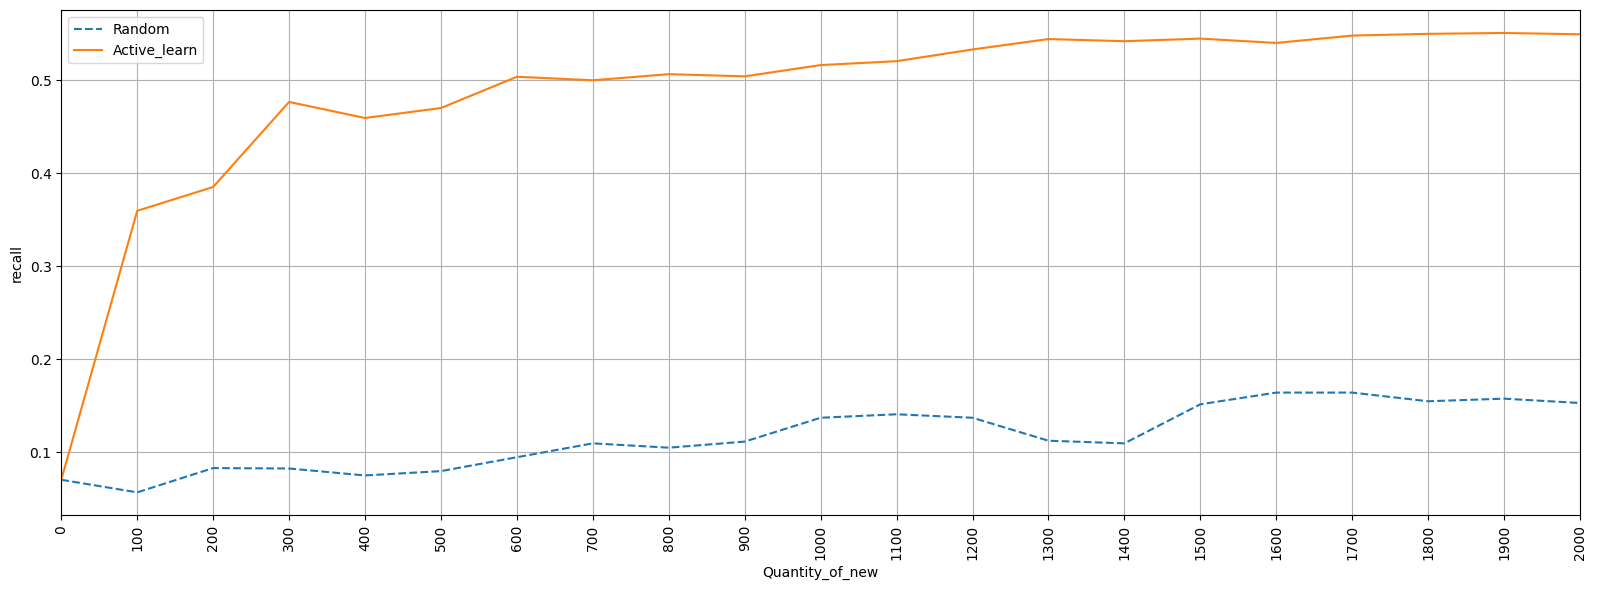

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(16, 6))


ax.plot(mas_of_x, mas_of_y_r,linestyle='--', label='Random')
ax.plot(mas_of_x, mas_of_y_a, linestyle='-', label='Active_learn')
ax.set_xlabel('Quantity_of_new')
ax.set_xticks(mas_of_x)
plt.xticks(rotation=90)
ax.set_ylabel('recall')
ax.legend()
plt.tight_layout()
plt.grid()
plt.margins(x=0)
plt.show()